## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with analyzing the data, developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Installing and Importing the necessary libraries**

In [1]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install -U sentence-transformers==4.1.0 gensim==4.3.3 transformers==4.52.4 tqdm==4.67.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.7/345.7 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 75.6 MB/s eta 0:00:00
  Attempting uninstall: tqdm
    Found existing installation: tqdm 4.67.3
    Uninstalling tqdm-4.67.3:
      Successfully unin

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [1]:
# To manipulate and analyze data
import pandas as pd
import numpy as np

# To visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# To used time-related functions
import time

# To parse JSON data
import json

# To build, tune, and evaluate ML models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# To load/create word embeddings
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

# To work with transformer models
import torch
from sentence_transformers import SentenceTransformer

# To implement progress bar related functionalities
from tqdm import tqdm
#tqdm.pandas()

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

## **Loading the dataset**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
stock_news = pd.read_csv("/content/drive/MyDrive/MLProjects/StockAnalysis/stock_news.csv") # Complete the code to read the CSV file.

In [4]:
#Creating a copy of the dataset
stock = stock_news.copy()

## **Data Overview**

### Displaying the first few rows of the dataset

In [ ]:
stock.head() # Complete the code to check the first 5 rows of the data

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,The tech sector experienced a significant dec...,41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,This news article reports that yields on long...,41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,Apple's revenue warning led to a decline in U...,41.740002,42.244999,41.482498,40.246914,130672400,-1


### Understanding the shape of the dataset

In [ ]:
stock.shape# Complete the code to check the shape of the data

(349, 8)

### Checking the data types of the columns

In [ ]:
stock.info() # Complete the code to check the data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB


In [ ]:
stock['Date'] = pd.to_datetime(stock['Date'])  # to convert the 'Date' column in the 'stock' DataFrame to datetime format.

### Checking the statistical summary

In [ ]:
stock.describe() # Complete the code to check the statistical summary

,Open,High,Low,Close,Volume,Label
count,349.000000,349.000000,349.000000,349.000000,3.490000e+02,349.000000
mean,46.229233,46.700458,45.745394,44.926317,1.289482e+08,-0.054441
std,6.442817,6.507321,6.391976,6.398338,4.317031e+07,0.715119
min,37.567501,37.817501,37.305000,36.254131,4.544800e+07,-1.000000
25%,41.740002,42.244999,41.482498,40.246914,1.032720e+08,-1.000000
50%,45.974998,46.025002,45.639999,44.596924,1.156272e+08,0.000000
75%,50.707500,50.849998,49.777500,49.110790,1.511252e+08,0.000000
max,66.817497,67.062500,65.862503,64.805229,2.444392e+08,1.000000


### Checking the duplicate values

In [ ]:
stock.duplicated().sum() #Complete the code to check the duplicate values

0

### Checking for missing values

In [ ]:
stock.isnull().sum() # Complete the code to check for missing values in the data

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


## **Exploratory Data Analysis**

### Univariate Analysis

#### Observations on Label

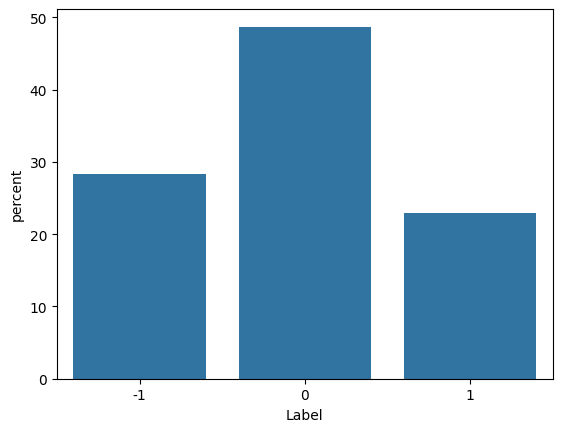

In [ ]:
sns.countplot(data=stock, x="Label", stat="percent");

#### Observations on Label

*   The dataset shows a distribution of sentiments: approximately **48% of the news articles are neutral (0)**, about **24% are negative (-1)**, and roughly **28% are positive (1)**.
*    Neutral sentiment is the most frequent category.

#### Density Plot of Price (Open,High,Low,Close)

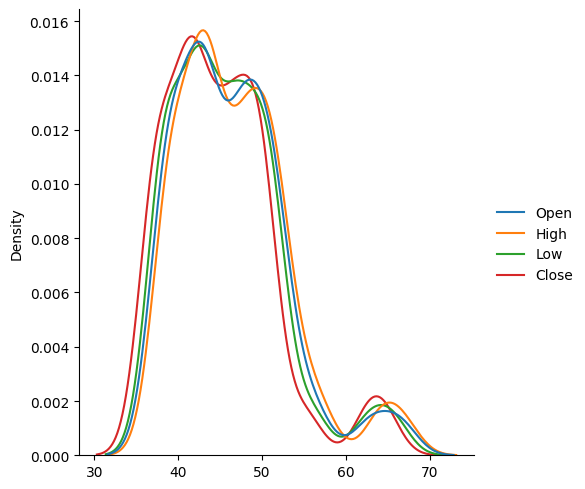

In [ ]:
sns.displot(data=stock[['Open','High','Low','Close']], kind="kde", palette="tab10"); # Complete the code to plot a density plot of ["Open","High","Low","Close"] all in a single plot

*   The density plot shows that the distributions of 'Open', 'High', 'Low', and 'Close' prices are quite similar, indicating a strong correlation between these price metrics.
*   All four price variables exhibit a bimodal distribution, suggesting two distinct clusters of common price ranges.
*   The peaks in the density occur roughly around the low 40s and the high 50s to low 60s, implying that the stock spent more time in these price ranges during the observed period.
*   The distributions are right-skewed, indicating that higher prices are less frequent but extend over a wider range, while lower prices are more concentrated.

#### Observations on Volume

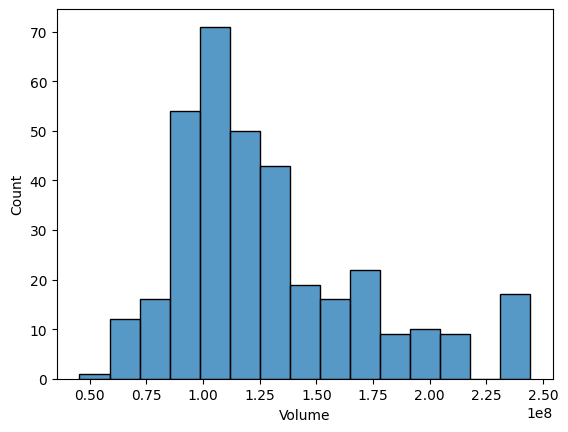

In [ ]:
sns.histplot(stock, x='Volume'); # Complete the code to plot a histogram of Volume

#### Observations on Volume

*   The histogram of 'Volume' shows a right-skewed distribution, indicating that lower trading volumes are more frequent than higher volumes.
*   The majority of trading days have volumes concentrated between approximately 80 million and 160 million shares.
*   There are fewer instances of very high trading volumes, suggesting that unusually large trading activities are less common.
*   The presence of a long tail to the right indicates that while rare, some days experience significantly higher trading volumes, possibly due to major news events or market reactions.

In [ ]:
#Calculating the total number of words present in the news content.
stock['news_len'] = stock['News'].apply(lambda x: len(x.split(' ')))


stock['news_len'].describe()    #Complete the code to print the statistical summary for the news content length

,news_len
count,349.000000
mean,49.312321
std,5.727770
min,19.000000
25%,46.000000
50%,50.000000
75%,53.000000
max,61.000000


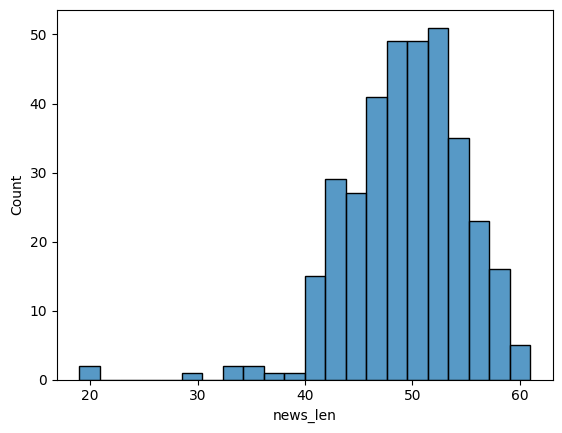

In [ ]:
sns.histplot(data=stock,x="news_len"); #Complete the code to plot a histogram of news_len column

### Bivariate Analysis

#### Correlation

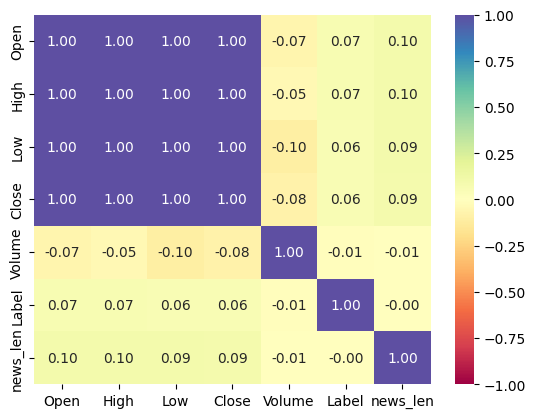

In [ ]:
sns.heatmap(
    stock.select_dtypes(include=np.number).corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
);    #Complete the code to plot the correlation matrix for numeric columns only.

#### Observations on Correlation Matrix

*   **High Correlation among Price Metrics**: 'Open', 'High', 'Low', and 'Close' prices are highly and positively correlated with each other (correlation coefficients close to 1). This is expected, as these values typically move together throughout a trading day.
*   **Low Correlation with Volume**: 'Volume' shows very little correlation with the price metrics ('Open', 'High', 'Low', 'Close'), as well as with 'Label' and 'news_len'. This suggests that trading volume doesn't directly dictate the direction or magnitude of daily price changes, nor is it strongly linked to the sentiment of news articles or their length.
*   **Sentiment (Label) and News Length (news_len)**: Both 'Label' and 'news_len' exhibit very low correlation with all other numerical features, including the stock prices and trading volume. This indicates that neither the sentiment of the news nor the length of the news article has a strong linear relationship with the stock's daily price movements or trading activity in this dataset.

#### Label vs Price (Open, High, Low, Close)

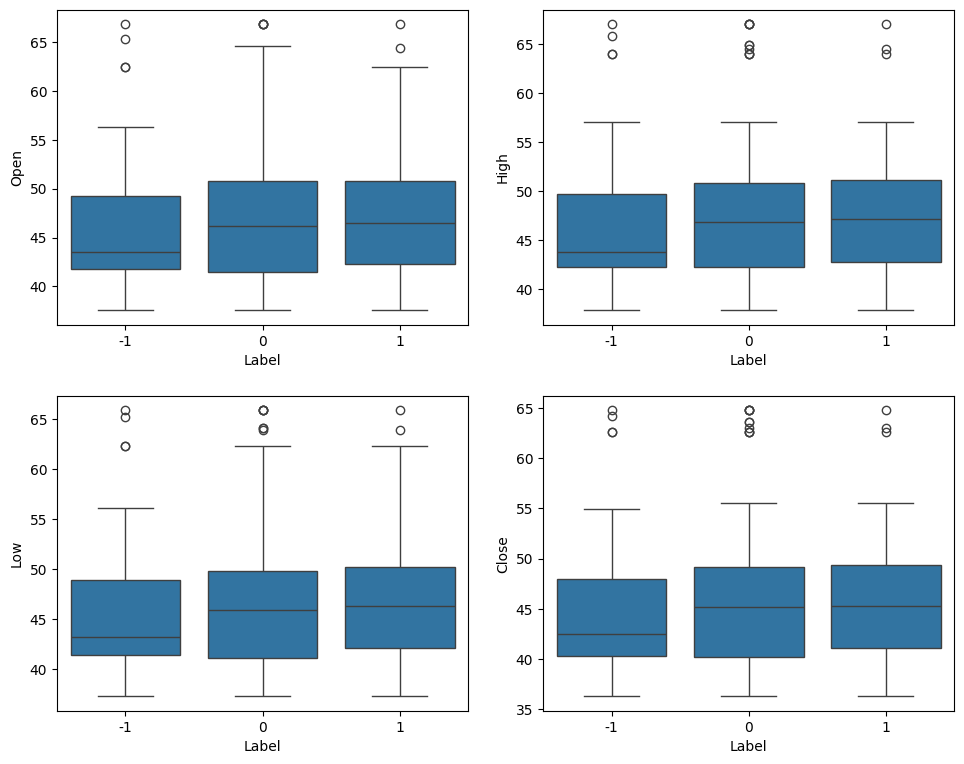

In [ ]:
plt.figure(figsize=(10, 8))

for i, variable in enumerate(['Open', 'High', 'Low', 'Close']):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=stock, x="Label", y=variable)
    plt.tight_layout(pad=2)

plt.show()

- **Similar Price Ranges Across Sentiments:** For all four price metrics (Open, High,
Low, and Close), the median and interquartile ranges appear to be quite similar across negative, neutral, and positive news labels. This suggests that the immediate daily price levels themselves (opening, highest, lowest, and closing) do not show a dramatically different central tendency based solely on the news sentiment label.
- **Overlap in Distributions:** There is significant overlap in the box plots for each sentiment category, indicating that the range of prices observed for negative news is largely similar to the range observed for neutral and positive news.
- **Presence of Outliers:** Each sentiment category shows outliers, particularly on the higher end of the price spectrum. These outliers represent instances where prices were significantly higher or lower than the typical range for a given sentiment, which could be due to other market factors not captured by news sentiment alone.
- **Limited Impact of Sentiment on Price Level:** Based on these plots, there isn't a strong visual indication that a positive news sentiment consistently leads to higher average stock prices, or that negative news consistently leads to lower average stock prices, within the observed daily ranges. The overall daily price movements seem to be influenced by factors beyond the categorical sentiment label alone.

#### Label vs Volume

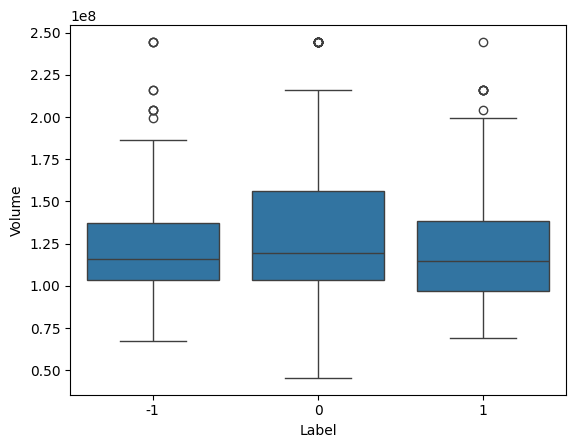

In [ ]:
sns.boxplot(
    data=stock, x="Label", y="Volume"  # Complete the code to plot a boxplot of Label vs Volume
);

- **Similar Median Volumes**: The median trading volumes (the line within each box) appear to be quite similar across all three sentiment categories (negative, neutral, and positive). This suggests that, on average, the daily trading volume is not significantly different regardless of whether the news sentiment is negative, neutral, or positive.
- **Comparable Interquartile Ranges:** The interquartile ranges (the boxes themselves) for volume are also similar across the sentiment labels. This indicates that the typical variability in trading volume around the median is consistent for all sentiment types.
- **Outliers Present:** All sentiment categories show a number of outliers, particularly on the higher end of the volume spectrum. These outliers represent days with exceptionally high trading volumes that fall outside the usual range, regardless of the news sentiment. This suggests that while sentiment might not dictate the typical volume, certain events (which might be associated with these outlier volumes) could coincide with various sentiments.
- **Weak Relationship between Sentiment and Volume:** Similar to the price metrics, there doesn't appear to be a strong direct relationship between the categorical news sentiment and the total trading volume. High or low volumes are observed across all sentiment types, implying that trading activity is likely driven by other factors alongside or independently of the sentiment conveyed in the news.

#### Date vs Price (Open, High, Low, Close)

In [ ]:
stock_daily = stock.groupby('Date').agg(
    {
        'Open': 'mean',
        'High': 'mean',
        'Low': 'mean',
        'Close': 'mean',
        'Volume': 'mean',
    }
).reset_index()  # Group the 'stocks' DataFrame by the 'Date' column

stock_daily.set_index('Date', inplace=True)
stock_daily.head()

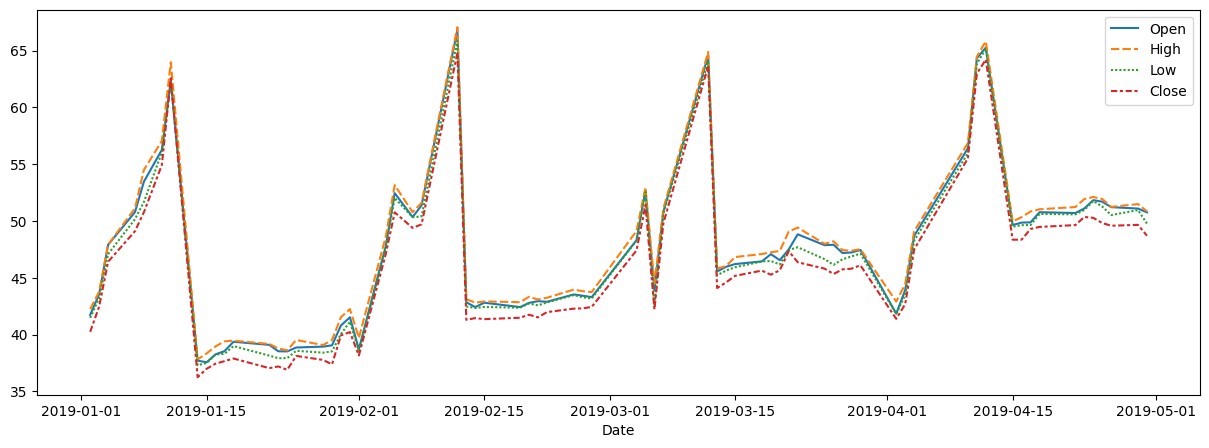

In [ ]:
stock_daily = stock.groupby('Date').agg(
    {
        'Open': 'mean',
        'High': 'mean',
        'Low': 'mean',
        'Close': 'mean',
        'Volume': 'mean',
    }
).reset_index()

stock_daily.set_index('Date', inplace=True)

plt.figure(figsize=(15,5))
sns.lineplot(stock_daily.drop("Volume", axis=1)); #Complete the code to plot a lineplot of all the variables except Volume

**General Trend:** All four price metrics (Open, High, Low, Close) track each other very closely, as expected. This indicates that the daily mean prices are highly consistent throughout the trading day. The stock shows periods of both upward and downward trends over the observed period.

**Volatility:** There are noticeable fluctuations, with periods of sharp increases followed by corrections, demonstrating the inherent volatility of stock prices.

**Overall Movement** The stock generally starts the period (January 2019) at a certain level, dips slightly, then experiences a significant upward trend towards the end of the period (April 2019), reaching higher price points.

#### Volume vs Close Price

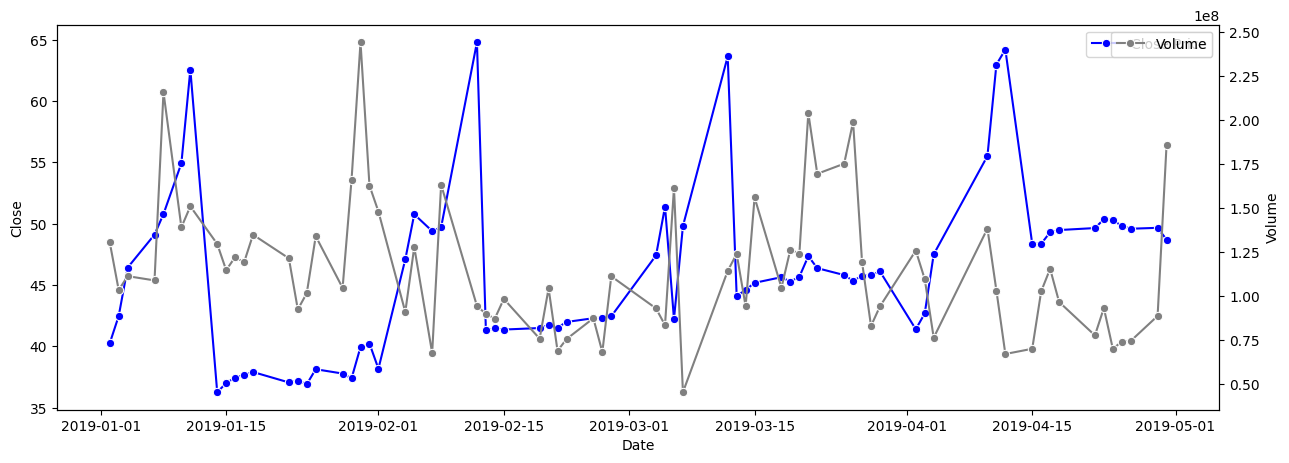

In [ ]:
# Create a figure and axis
fig, ax1 = plt.subplots(figsize=(15,5))

# Lineplot on primary y-axis
sns.lineplot(data=stock_daily.reset_index(), x='Date', y='Close', ax=ax1, color='blue', marker='o', label='Close Price')

# Create a secondary y-axis
ax2 = ax1.twinx()

# Lineplot on secondary y-axis
sns.lineplot(data=stock_daily.reset_index(), x='Date', y='Volume', ax=ax2, color='gray', marker='o', label='Volume')

ax1.legend(bbox_to_anchor=(1,1));

**Volume vs Close Price (Combined Plot):**

**-Price and Volume Dynamics:** This plot overlays the Close Price and Volume trends over time. While the Close Price shows a distinct pattern of fluctuation and an overall upward trend, the Volume trend appears less directly correlated with immediate price movements.

**Volume Spikes:** There are instances where trading volume significantly spikes. These spikes sometimes coincide with notable price movements (either up or down), suggesting that major news or events might be driving both increased trading activity and price changes. However, there are also high volume days with relatively stable prices, and significant price changes on days with average volume.
**No Strong Direct Correlation:** Similar to the box plots, this time-series view reinforces that high or low volumes don't always correspond to a particular direction or magnitude of price change. Instead, volume often reflects overall market interest or reaction to information, which might or might not translate into a direct, predictable price movement on that specific day.

## **Data Preprocessing**

In [5]:
stock["Date"].describe() #Complete the code to print the statistical summary of the 'Date' column

,Date
count,349
unique,71
top,2019-01-03
freq,28


### Train-test-validation Split

In [6]:
X_train = stock[(stock['Date'] < '2019-04-01')].reset_index()    #Complete the code to select all rows where the 'Date' is before '2019-04-01'
X_val = stock[(stock['Date'] >= '2019-04-01') & (stock['Date'] < '2019-04-16')].reset_index()    #Complete the code to select all rows where the 'Date' is from '2019-04-01 to '2019-04-16' (excluded)
X_test = stock[stock['Date'] >= '2019-04-16'].reset_index()    #Complete the code to select all rows where the 'Date' is from '2019-04-16' till the end.

In [7]:
# Complete the code to pick the 'Label' column as the target variable
y_train = X_train["Label"].copy()
y_val = X_val["Label"].copy()
y_test = X_test["Label"].copy()

In [8]:
#Complete the code to print the shape of X_train,X_val,X_test,y_train,y_val and y_test
print("Train data shape",X_train.shape)
print("Validation data shape",X_val.shape)
print("Test data shape ",X_test.shape)

print("Train label shape",y_train.shape)
print("Validation label shape",y_val.shape)
print("Test label shape ",y_test.shape)

Train data shape (286, 9)
Validation data shape (21, 9)
Test data shape  (42, 9)
Train label shape (286,)
Validation label shape (21,)
Test label shape  (42,)


## **Word Embeddings**

### Word2Vec

In [9]:
# Creating a list of all words in our data
words_list = [item.split(" ") for item in stock['News'].values]

In [10]:
# Creating an instance of Word2Vec
vec_size = 300
model_W2V = Word2Vec(words_list, vector_size = vec_size, min_count = 1, window=5, workers = 6)

In [11]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(list(model_W2V.wv.key_to_index)))

Length of the vocabulary is 4682


Let's check out a few word embeddings obtained using the model.

In [12]:
# Checking the word embedding of a random word
word = "stock"
model_W2V.wv[word]

array([-4.42911312e-03,  3.76143493e-02,  8.37580394e-03,  1.16199655e-02,
        1.36822765e-03, -5.75528778e-02,  2.87515186e-02,  8.76506940e-02,
        3.79533414e-03, -2.19714213e-02,  6.23928802e-03, -2.08236706e-02,
       -4.87882504e-03,  1.52156241e-02, -2.54476294e-02, -2.73039006e-02,
        2.33845823e-02, -4.24031867e-03,  6.73004799e-03, -2.47344002e-02,
       -2.28162874e-02,  8.15975480e-03,  2.96021532e-02,  1.49404602e-02,
        2.45514847e-02,  7.24411511e-04, -3.55896503e-02,  8.77011660e-03,
       -2.89343409e-02, -4.11327556e-02,  9.90616716e-03, -2.76231207e-02,
        5.03869401e-03, -8.46250448e-03, -1.66119286e-03,  2.31830832e-02,
        1.24027254e-02, -3.44215073e-02, -2.56697345e-03, -1.23107368e-02,
       -2.04758942e-02,  3.48075060e-03, -4.12272311e-05, -2.09790580e-02,
        2.02075578e-02,  3.81897092e-02,  8.95291753e-03,  1.77237634e-02,
        2.47999968e-04,  2.37386022e-02,  1.22170104e-02, -9.02374741e-03,
       -2.08575670e-02,  

In [13]:
# Checking the word embedding of a random word
word = "economy"
model_W2V.wv[word]

array([-1.21648598e-03,  5.19822538e-03,  3.24421469e-03,  1.91657187e-03,
       -1.10487908e-03, -1.14159985e-02,  6.67332858e-03,  1.55839743e-02,
       -1.96207222e-03, -2.17233924e-03, -2.40440434e-03, -3.45537113e-03,
        7.66628073e-04, -2.65193550e-04, -4.19363612e-03, -1.79273786e-03,
        7.25810928e-03,  1.87027454e-03,  3.73963243e-03, -2.68821372e-03,
       -5.78416651e-03,  2.82994099e-03,  3.94850690e-03, -8.27258162e-04,
        1.26641023e-03, -1.20798615e-03, -7.12460512e-03,  2.30496842e-03,
       -6.65499177e-03, -9.64063499e-03, -1.99984852e-03, -6.59116590e-03,
        2.96388031e-03, -2.64221500e-03, -2.66428012e-03,  5.87756280e-03,
       -1.73560446e-04, -5.38247498e-03, -7.73452193e-05, -2.94199260e-03,
       -5.80520788e-03,  7.60415627e-04,  1.42162305e-03, -3.93304462e-03,
        3.95129528e-03,  3.83742503e-03, -5.97027829e-04,  1.11981411e-03,
       -1.70564854e-05,  1.05791411e-03,  4.71321633e-03, -4.12041089e-03,
       -4.10426082e-03,  

In [14]:
# Retrieving the words present in the Word2Vec model's vocabulary
words = list(model_W2V.wv.key_to_index.keys())

# Retrieving word vectors for all the words present in the model's vocabulary
wvs = model_W2V.wv[words].tolist()

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = dict(zip(words, wvs))

In [15]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [16]:
# creating a dataframe of the vectorized documents
start = time.time()

X_train_wv = pd.DataFrame(X_train["News"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_val_wv = pd.DataFrame(X_val["News"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_test_wv = pd.DataFrame(X_test["News"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])

end = time.time()
print('Time taken ', (end-start))

Time taken  0.5631570816040039


In [17]:
print(X_train_wv.shape, X_val_wv.shape, X_test_wv.shape)

(286, 300) (21, 300) (42, 300)


### GloVe

In [18]:
import os
from gensim.scripts.glove2word2vec import glove2word2vec
from gensim.models import KeyedVectors

# Define filenames
glove_input_file = '/content/drive/MyDrive/MLProjects/StockAnalysis/glove.6B.100d.txt'
word2vec_output_file = '/content/drive/MyDrive/MLProjects/StockAnalysis/glove.6B.100d.txt.word2vec'

# Check if the GloVe file in word2vec format already exists
if not os.path.exists(word2vec_output_file):
    print(f"'{word2vec_output_file}' not found. Checking for '{glove_input_file}'.")

    # Check if the original GloVe file exists
    if not os.path.exists(glove_input_file):
        print(f"'{glove_input_file}' not found. Attempting to download from a public source.")
        # Download the GloVe file (using -nc for no-clobber to avoid re-downloading if partially present)
        try:
            !wget -nc https://huggingface.co/stanfordnlp/glove/resolve/main/glove.6B.100d.txt
            print("Download complete.")
        except Exception as e:
            print(f"Error downloading GloVe file: {e}. Please ensure internet connectivity or manually place '{glove_input_file}' in the current directory.")
            raise FileNotFoundError(f"Could not find or download '{glove_input_file}'.")

    # Convert the GloVe format to Word2Vec format
    print(f"Converting '{glove_input_file}' to '{word2vec_output_file}'...")
    glove2word2vec(glove_input_file, word2vec_output_file)
    print("Conversion complete.")

# Load the Stanford GloVe model in word2vec format
filename = word2vec_output_file
glove_model = KeyedVectors.load_word2vec_format(filename, binary=False)

In [19]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(glove_model.index_to_key))

Length of the vocabulary is 400000


Let's check out a few word embeddings.

In [20]:
# Checking the word embedding of a random word
word = "stock"
glove_model[word]

array([ 8.6341e-01,  6.9648e-01,  4.5794e-02, -9.5708e-03, -2.5498e-01,
       -7.4666e-01, -2.2086e-01, -4.4615e-01, -1.0423e-01, -9.9931e-01,
        7.2550e-02,  4.5049e-01, -5.9912e-02, -5.7837e-01, -4.6540e-01,
        4.3429e-02, -5.0570e-01, -1.5442e-01,  9.8250e-01, -8.1571e-02,
        2.6523e-01, -2.3734e-01,  9.7675e-02,  5.8588e-01, -1.2948e-01,
       -6.8956e-01, -1.2811e-01, -5.2265e-02, -6.7719e-01,  3.0190e-02,
        1.8058e-01,  8.6121e-01, -8.3206e-01, -5.6887e-02, -2.9578e-01,
        4.7180e-01,  1.2811e+00, -2.5228e-01,  4.9557e-02, -7.2455e-01,
        6.6758e-01, -1.1091e+00, -2.0493e-01, -5.8669e-01, -2.5375e-03,
        8.2777e-01, -4.9102e-01, -2.6475e-01,  4.3015e-01, -2.0516e+00,
       -3.3208e-01,  5.1845e-02,  5.2646e-01,  8.7452e-01, -9.0237e-01,
       -1.7366e+00, -3.4727e-01,  1.6590e-01,  2.7727e+00,  6.5756e-02,
       -4.0363e-01,  3.8252e-01, -3.0787e-01,  5.9202e-01,  1.3468e-01,
       -3.3851e-01,  3.3646e-01,  2.0950e-01,  8.5905e-01,  5.18

In [21]:
# Checking the word embedding of a random word
word = "economy"
glove_model[word]

array([-0.19382  ,  1.017    ,  1.076    ,  0.02954  , -0.39192  ,
       -1.3891   , -0.87873  , -0.63162  ,  0.9643   , -0.43035  ,
       -0.34868  ,  0.22736  , -0.40296  ,  0.15641  , -0.16813  ,
       -0.15343  , -0.15799  , -0.27612  ,  0.18088  , -0.28386  ,
        0.49847  ,  0.29864  ,  0.32353  ,  0.18108  , -0.59623  ,
       -0.54165  , -0.70019  , -0.64956  , -0.69063  ,  0.18084  ,
       -0.38581  ,  0.56086  , -0.40313  , -0.38777  , -0.70615  ,
        0.20657  ,  0.34171  , -0.23393  , -0.35882  , -0.2201   ,
       -0.76182  , -1.2047   ,  0.4339   ,  1.1656   ,  0.1836   ,
       -0.21601  ,  0.93198  , -0.059616 , -0.11624  , -1.3259   ,
       -0.79772  , -0.0074957, -0.0889   ,  1.4749   ,  0.31157  ,
       -2.2952   , -0.058351 ,  0.39353  ,  1.4983   ,  0.74023  ,
       -0.20109  ,  0.098124 , -0.73081  , -0.32294  ,  0.16703  ,
        0.87431  , -0.041624 , -0.51022  ,  1.0737   , -0.4257   ,
        1.0581   ,  0.19859  , -0.60087  , -0.33906  ,  0.6024

In [22]:
# Retrieving the words present in the GloVe model's vocabulary
glove_words = glove_model.index_to_key

# Creating a dictionary of words and their corresponding vectors
glove_word_vector_dict = dict(zip(glove_model.index_to_key,list(glove_model.vectors)))

In [23]:
vec_size=100

In [24]:
def average_vectorizer_GloVe(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in glove_words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(glove_word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [25]:
# creating a dataframe of the vectorized documents
start = time.time()

X_train_gl = pd.DataFrame(X_train["News"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)]) #Complete the code to apply GloVe on 'News' column
X_val_gl = pd.DataFrame(X_val["News"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)]) #Complete the code to apply GloVe on 'News' column
X_test_gl = pd.DataFrame(X_test["News"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)]) #Complete the code to apply GloVe on 'News' column

end = time.time()
print('Time taken ', (end-start))

Time taken  29.61285710334778


In [ ]:
print(X_train_gl.shape, X_val_gl.shape, X_test_gl.shape) #Complete the code to print the shapes of the final dataframes

(286, 100) (21, 100) (42, 100)


### Sentence Transformer

#### Defining the model

In [26]:
#Defining the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

#### Encoding the dataset

In [27]:
# setting the device to GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [28]:
# encoding the dataset
start = time.time()

X_train_st = model.encode(X_train["News"].values, show_progress_bar=True, device=device) #Complete the code to apply Sentence Transformer on 'News' column
X_val_st = model.encode(X_val["News"].values, show_progress_bar=True, device=device) #Complete the code to apply Sentence Transformer on 'News' column
X_test_st = model.encode(X_test["News"].values, show_progress_bar=True, device=device) #Complete the code to apply Sentence Transformer on 'News' column

end = time.time()
print("Time taken ",(end-start))

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Time taken  1.1764965057373047


In [29]:
print(X_train_st.shape, X_val_st.shape, X_test_st.shape) #Complete the code to print the shapes of the final dataframes

(286, 384) (21, 384) (42, 384)


- Each news content has been converted to a 384-dimensional vector.

## **Sentiment Analysis**

### Model Evaluation Criterion

**Model is right:**
When the model correctly predicts the sentiment. eg. predicts 'positive' and it is 'positive' or predicts 'negative' and it is 'negative'.

**Model is wrong:**
When the model incorrectly predicts the sentiment ge. predicts 'positive' but it was 'negative' or 'neutral'

**High precision** means fewer false positives. In sentiment analysis, high precision for 'positive' sentiment means that when the models says an article is possible, it's very likely to be genuinely positive. This is crucial if misclassifying a negative as positive has high costs.

**High recall** means fewer false negatives. In sentinent analysis, high recall for negaive sentiment means the model is good at catching most of the truly negative news, which is important for risk assessment.

F1-score is a better metric to look at as both false postives and false negatives have similar costs. For multi-clsass classification the fi_weighted or f1_macro is a better metric


### Utility Functions

In [30]:
def plot_confusion_matrix(model, predictors, target):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """
    pred = model.predict(predictors)  # Make predictions using the classifier.

    cm = confusion_matrix(target, pred)  # Compute the confusion matrix.

    plt.figure(figsize=(5, 4))  # Create a new figure with a specified size.
    label_list = [0, 1,-1]  # Define the labels for the confusion matrix.
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)
    # Plot the confusion matrix using a heatmap with annotations.

    plt.ylabel('Actual')  # Label for the y-axis.
    plt.xlabel('Predicted')  # Label for the x-axis.
    plt.title('Confusion Matrix')  # Title of the plot.
    plt.show()  # Display the plot.

In [31]:
def model_performance_classification_sklearn(model, predictors, target):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """
    pred = model.predict(predictors)  # Make predictions using the classifier.

    acc = accuracy_score(target, pred)  # Compute Accuracy.
    recall = recall_score(target, pred,average='weighted')  # Compute Recall.
    precision = precision_score(target, pred,average='weighted')  # Compute Precision.
    f1 = f1_score(target, pred,average='weighted')  # Compute F1-score.

    # Create a DataFrame to store the computed metrics.
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )

    return df_perf  # Return the DataFrame with the metrics.

### Decision Tree - Word2Vec

In [32]:
# Building the model

base_wv = DecisionTreeClassifier(random_state=42)

# Fitting on train data
base_wv.fit(X_train_wv, y_train)

DecisionTreeClassifier(random_state=42)

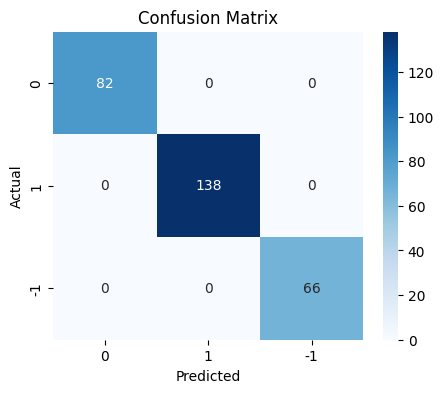

In [33]:
plot_confusion_matrix(base_wv,X_train_wv,y_train)

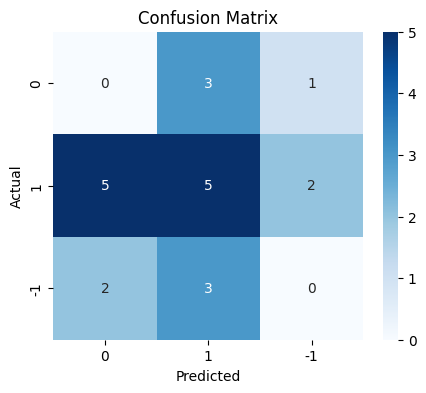

In [34]:
plot_confusion_matrix(base_wv,X_val_wv,y_val)

In [35]:
#Calculating different metrics on training data
base_train_wv = model_performance_classification_sklearn(base_wv,X_train_wv,y_train)
print("Training performance:\n", base_train_wv)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [36]:
#Calculating different metrics on validation data
base_val_wv = model_performance_classification_sklearn(base_wv,X_val_wv,y_val)
print("Validation performance:\n",base_val_wv)

Validation performance:
    Accuracy    Recall  Precision        F1
0  0.238095  0.238095    0.25974  0.248447


### GradientBoostingClassifier - Word2Vec

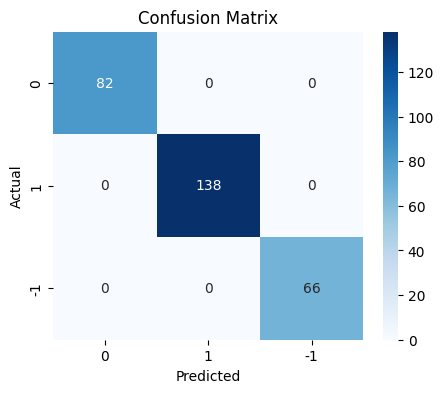

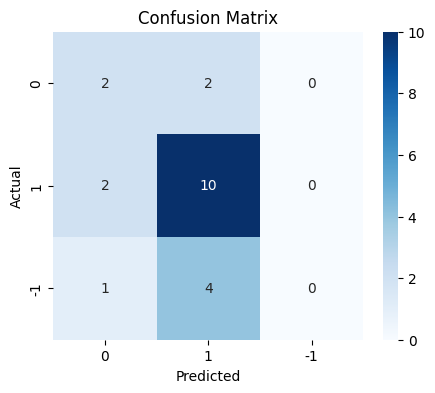

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0
Validation performance:
    Accuracy    Recall  Precision        F1
0  0.571429  0.571429   0.433333  0.492819


In [37]:
import warnings
warnings.filterwarnings('ignore')

# Building the model
base_gb_wv = GradientBoostingClassifier(random_state=42)

# Fitting on train data using Word2Vec embeddings (X_train_wv)
base_gb_wv.fit(X_train_wv, y_train)

# Plot confusion matrix for training data
plot_confusion_matrix(base_gb_wv, X_train_wv, y_train)

# Plot confusion matrix for validation data
plot_confusion_matrix(base_gb_wv, X_val_wv, y_val)

# Calculating different metrics on training data
base_train_gb_wv = model_performance_classification_sklearn(base_gb_wv, X_train_wv, y_train)
print("Training performance:\n", base_train_gb_wv)

# Calculating different metrics on validation data
base_val_gb_wv = model_performance_classification_sklearn(base_gb_wv, X_val_wv, y_val)
print("Validation performance:\n", base_val_gb_wv)

The validation performance is significantly lower than the training performance. The accuracy of approximately 52% and an F1-score of about 46% suggest that the model is struggling to generalize to the validation data. This further supports the observation of overfitting from the training metrics.

### Random Forest - - Word2Vec

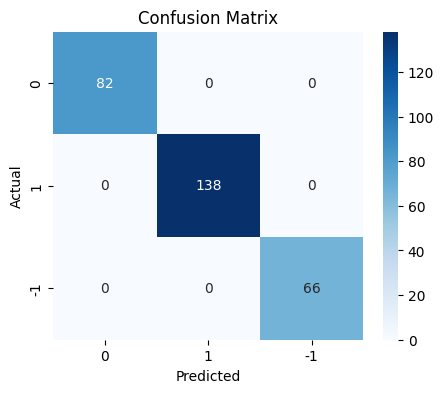

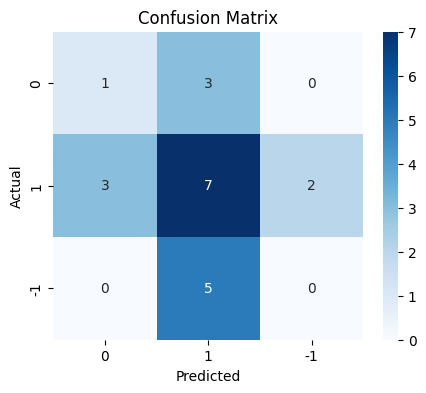

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0
Validation performance:
    Accuracy    Recall  Precision        F1
0  0.380952  0.380952   0.314286  0.343915


In [38]:
import warnings
warnings.filterwarnings('ignore')

# Building the model
base_rf_wv = RandomForestClassifier(random_state=42)

# Fitting on train data using Word2Vec embeddings (X_train_wv)
base_rf_wv.fit(X_train_wv, y_train)

# Plot confusion matrix for training data
plot_confusion_matrix(base_rf_wv, X_train_wv, y_train)

# Plot confusion matrix for validation data
plot_confusion_matrix(base_rf_wv, X_val_wv, y_val)

# Calculating different metrics on training data
base_train_rf_wv = model_performance_classification_sklearn(base_rf_wv, X_train_wv, y_train)
print("Training performance:\n", base_train_rf_wv)

# Calculating different metrics on validation data
base_val_rf_wv = model_performance_classification_sklearn(base_rf_wv, X_val_wv, y_val)
print("Validation performance:\n", base_val_rf_wv)

The validation performance is significantly lower than the training performance. An accuracy of approximately 33% and an F1-score of around 28% indicate that the model performs poorly on the validation dataset. This confirms the overfitting observed in the training metrics.



### Decision Tree - GloVe

In [39]:
#Building the model


base_wv = DecisionTreeClassifier(random_state=42)

# Fitting on train data
base_wv.fit(X_train_gl, y_train) #Complete the code to fit the chosen model on the train data

DecisionTreeClassifier(random_state=42)

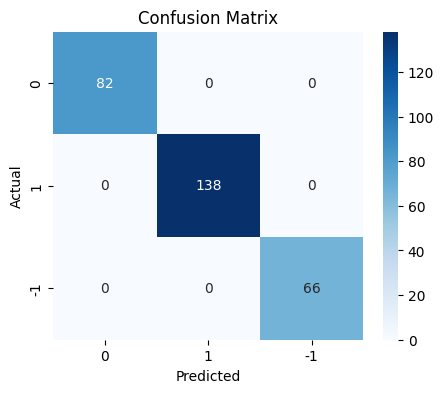

In [40]:
plot_confusion_matrix(base_wv,X_train_gl,y_train) #Complete the code to plot the confusion matrix for the train data

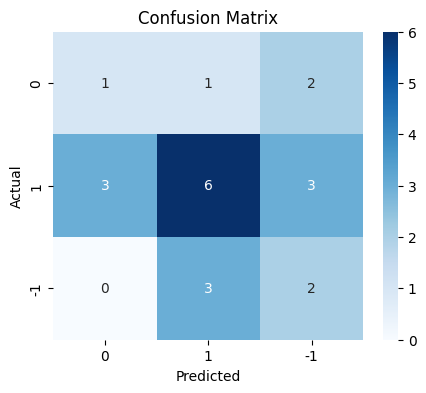

In [41]:
plot_confusion_matrix(base_wv,X_val_gl,y_val) #Complete the code to plot the confusion matrix for the validation data

In [42]:
#Calculating different metrics on training data
base_train_gl=model_performance_classification_sklearn(base_wv,X_train_gl,y_train) #Complete the code to compute the model performance for the training data
print("Training performance:\n", base_train_gl)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [43]:
#Calculating different metrics on validation data
base_val_gl = model_performance_classification_sklearn(base_wv,X_val_gl,y_val) #Complete the code to compute the model performance for the validation data
print("Validation performance:\n",base_val_gl)

Validation performance:
    Accuracy    Recall  Precision        F1
0  0.428571  0.428571   0.458503  0.438672


### Gradient Boosting Classifier - Glove

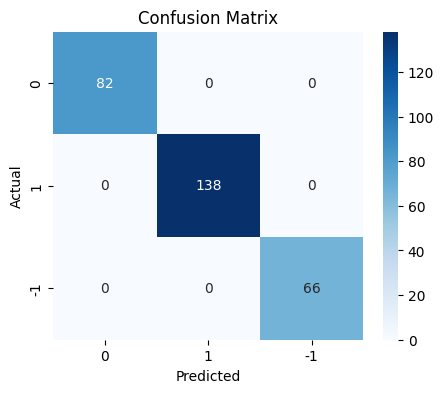

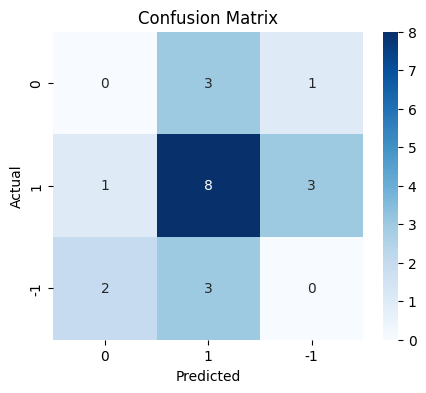

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0
Validation performance:
    Accuracy    Recall  Precision        F1
0  0.380952  0.380952   0.326531  0.351648


In [44]:
import warnings
warnings.filterwarnings('ignore')

# Building the model
base_gb_gl = GradientBoostingClassifier(random_state=42)

# Fitting on train data using GloVe embeddings (X_train_gl)
base_gb_gl.fit(X_train_gl, y_train)

# Plot confusion matrix for training data
plot_confusion_matrix(base_gb_gl, X_train_gl, y_train)

# Plot confusion matrix for validation data
plot_confusion_matrix(base_gb_gl, X_val_gl, y_val)

# Calculating different metrics on training data
base_train_gb_gl = model_performance_classification_sklearn(base_gb_gl, X_train_gl, y_train)
print("Training performance:\n", base_train_gb_gl)

# Calculating different metrics on validation data
base_val_gb_gl = model_performance_classification_sklearn(base_gb_gl, X_val_gl, y_val)
print("Validation performance:\n", base_val_gb_gl)

The validation performance is significantly lower than the training performance. An accuracy of approximately 38% and an F1-score of around 35% indicate that the model performs poorly on the validation dataset, suggesting severe overfitting.

### Random Forest Classifier - Glove

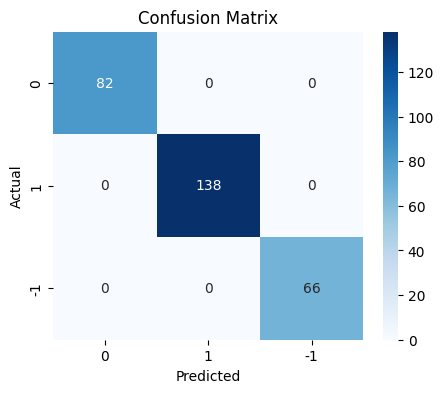

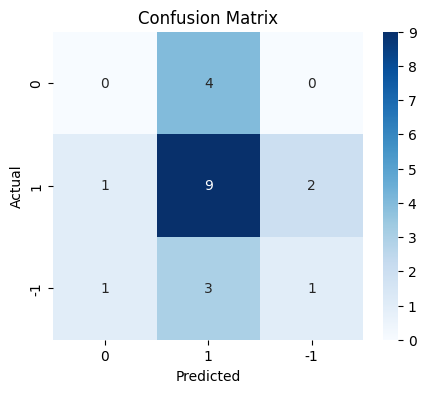

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0
Validation performance:
    Accuracy   Recall  Precision        F1
0   0.47619  0.47619   0.400794  0.426871


In [45]:
import warnings
warnings.filterwarnings('ignore')

# Building the model
base_rf_gl = RandomForestClassifier(random_state=42)

# Fitting on train data using GloVe embeddings (X_train_gl)
base_rf_gl.fit(X_train_gl, y_train)

# Plot confusion matrix for training data
plot_confusion_matrix(base_rf_gl, X_train_gl, y_train)

# Plot confusion matrix for validation data
plot_confusion_matrix(base_rf_gl, X_val_gl, y_val)

# Calculating different metrics on training data
base_train_rf_gl = model_performance_classification_sklearn(base_rf_gl, X_train_gl, y_train)
print("Training performance:\n", base_train_rf_gl)

# Calculating different metrics on validation data
base_val_rf_gl = model_performance_classification_sklearn(base_rf_gl, X_val_gl, y_val)
print("Validation performance:\n", base_val_rf_gl)

The validation performance is significantly lower than the training performance. An accuracy of approximately 47% and an F1-score of around 42% indicate that the model performs poorly on the validation dataset, suggesting severe overfitting.

### Decision Tree Classifier: SBERT

In [46]:
# Building the model

base_wv = DecisionTreeClassifier(random_state=42)

# Fitting on train data
base_wv.fit(X_train_st, y_train) #Complete the code to fit the chosen model on the train data

DecisionTreeClassifier(random_state=42)

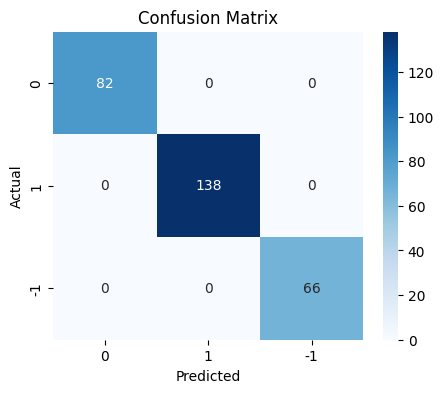

In [47]:
plot_confusion_matrix(base_wv,X_train_st,y_train) #Complete the code to plot the confusion matrix for the train data

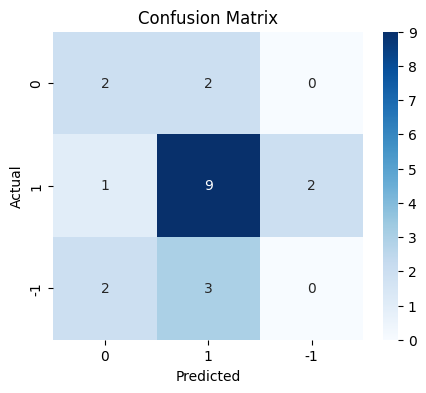

In [48]:
plot_confusion_matrix(base_wv,X_val_st,y_val) #Complete the code to plot the confusion matrix for the validation data

In [49]:
#Calculating different metrics on training data
base_train_st=model_performance_classification_sklearn(base_wv,X_train_st,y_train) #Complete the code to compute the model performance for the training data
print("Training performance:\n", base_train_st)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [50]:
#Calculating different metrics on validation data
base_val_st = model_performance_classification_sklearn(base_wv,X_val_st,y_val) #Complete the code to compute the model performance for the validation data
print("Validation performance:\n",base_val_st)

Validation performance:
    Accuracy   Recall  Precision       F1
0   0.52381  0.52381   0.443537  0.48026


### The validation performance is significantly lower than the training performance. The accuracy of approximately 52% and an F1-score of about 48% suggest that the model is struggling to generalize to the validation data. This further supports the observation of overfitting from the training metrics.

### Gradient Boosting- Sentence Transfomer

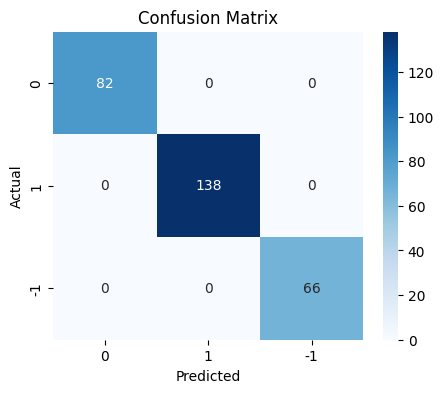

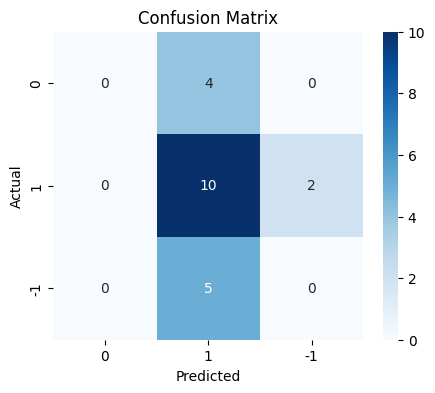

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0
Validation performance:
    Accuracy   Recall  Precision        F1
0   0.47619  0.47619   0.300752  0.368664


In [51]:
import warnings
warnings.filterwarnings('ignore')

# Building the model
base_gb_st = GradientBoostingClassifier(random_state=42)

# Fitting on train data using Sentence Transformer embeddings (X_train_st)
base_gb_st.fit(X_train_st, y_train)

# Plot confusion matrix for training data
plot_confusion_matrix(base_gb_st, X_train_st, y_train)

# Plot confusion matrix for validation data
plot_confusion_matrix(base_gb_st, X_val_st, y_val)

# Calculating different metrics on training data
base_train_gb_st = model_performance_classification_sklearn(base_gb_st, X_train_st, y_train)
print("Training performance:\n", base_train_gb_st)

# Calculating different metrics on validation data
base_val_gb_st = model_performance_classification_sklearn(base_gb_st, X_val_st, y_val)
print("Validation performance:\n", base_val_gb_st)

The validation performance is significantly lower than the training performance. An accuracy of approximately 47% and an F1-score of around 36% indicate that the model performs poorly on the validation dataset, suggesting severe overfitting.

### Random Forest- Sentence Transfomer

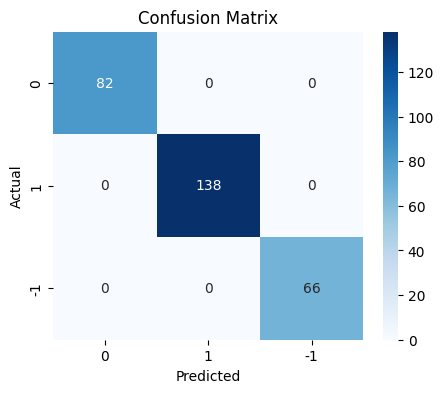

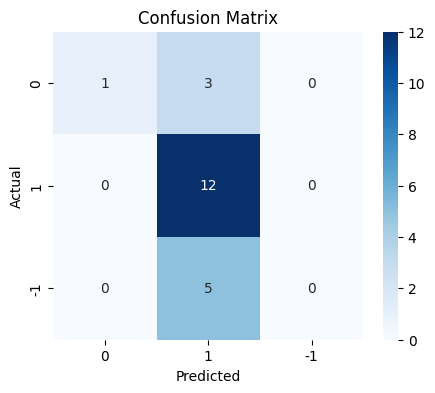

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0
Validation performance:
    Accuracy    Recall  Precision        F1
0  0.619048  0.619048   0.533333  0.504762


In [52]:
import warnings
warnings.filterwarnings('ignore')

# Building the model
base_rf_st = RandomForestClassifier(random_state=42)

# Fitting on train data using Sentence Transformer embeddings (X_train_st)
base_rf_st.fit(X_train_st, y_train)

# Plot confusion matrix for training data
plot_confusion_matrix(base_rf_st, X_train_st, y_train)

# Plot confusion matrix for validation data
plot_confusion_matrix(base_rf_st, X_val_st, y_val)

# Calculating different metrics on training data
base_train_rf_st = model_performance_classification_sklearn(base_rf_st, X_train_st, y_train)
print("Training performance:\n", base_train_rf_st)

# Calculating different metrics on validation data
base_val_rf_st = model_performance_classification_sklearn(base_rf_st, X_val_st, y_val)
print("Validation performance:\n", base_val_rf_st)

The validation performance is lower than the training performance. An accuracy of approximately 61% and an F1-score of around 50% indicate that while better than previous models, there is still some overfitting, and the model can be improved further for better generalization.

## Tuned model - RandomForest Sentence Transformer

Time taken  0.5803601741790771

Confusion Matrix for Training Data:


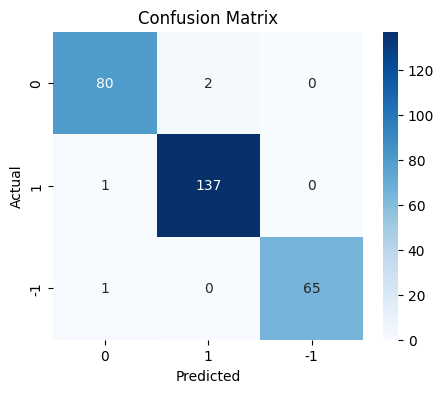


Confusion Matrix for Validation Data:


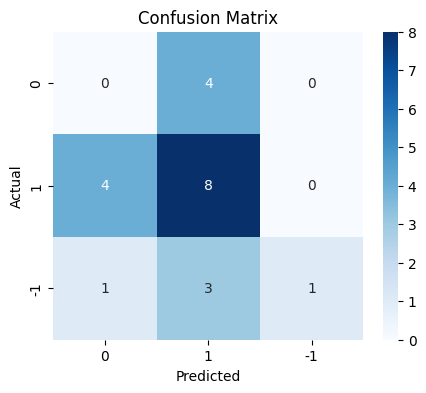


Training performance:
    Accuracy    Recall  Precision       F1
0  0.986014  0.986014   0.986064  0.98602

Validation performance:
    Accuracy    Recall  Precision        F1
0  0.428571  0.428571   0.542857  0.417989


In [62]:
start = time.time()

# Choose the type of classifier.
tuned_rf_st = RandomForestClassifier(random_state=42)

parameters = {
    'n_estimators': [5, 10, 1] # Number of trees in the forest
    #'max_depth': [5, 8, 10, 12],
    #'min_samples_split': [2, 5, 10, 15],
    #'max_features': ['sqrt', 'log2', 0.6, 0.8]
}

# Run the grid search
grid_obj_rf_st = GridSearchCV(tuned_rf_st, parameters, scoring='f1_weighted', cv=5, n_jobs=-1)
grid_obj_rf_st = grid_obj_rf_st.fit(X_train_st, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_rf_st = grid_obj_rf_st.best_estimator_

# Fit the best algorithm to the data (this is already done by GridSearchCV but explicit fit is good practice)
tuned_rf_st.fit(X_train_st, y_train)

# Plot confusion matrix for training data
print("\nConfusion Matrix for Training Data:")
plot_confusion_matrix(tuned_rf_st, X_train_st, y_train)

# Plot confusion matrix for validation data
print("\nConfusion Matrix for Validation Data:")
plot_confusion_matrix(tuned_rf_st, X_val_st, y_val)

# Calculating different metrics on training data
tuned_train_rf_st = model_performance_classification_sklearn(tuned_rf_st, X_train_st, y_train)
print("\nTraining performance:\n", tuned_train_rf_st)

# Calculating different metrics on validation data
tuned_val_rf_st = model_performance_classification_sklearn(tuned_rf_st, X_val_st, y_val)
print("\nValidation performance:\n", tuned_val_rf_st)

### Model Performance Summary and Final Model Selection

In [64]:
#training performance comparison

models_train_comp_df = pd.concat(
    [
        base_train_wv.T,
        base_train_gl.T,
        base_train_st.T,
        tuned_train_rf_st.T
    ],
    axis=1
)

models_train_comp_df.columns = [
    "Base Model (Word2Vec)",
    "Base Model (GloVe)",
    "Base Model (Sentence Transformer)",
    "Tuned Model (Sentence Transformer)",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Base Model (Word2Vec),Base Model (GloVe),Base Model (Sentence Transformer),Tuned Model (Sentence Transformer)
Accuracy,1.0,1.0,1.0,0.986014
Recall,1.0,1.0,1.0,0.986014
Precision,1.0,1.0,1.0,0.986064
F1,1.0,1.0,1.0,0.986020


In [66]:
#validation performance comparison

models_val_comp_df = pd.concat(
    [base_val_wv.T,
     base_val_gl.T,
     base_val_st.T,
     tuned_val_rf_st.T
     ],
    axis=1
)

models_val_comp_df.columns = [
    "Base Model (Word2Vec)",
    "Base Model (GloVe)",
    "Base Model (Sentence Transformer)",
    "Tuned Model (Sentence Transformer)",
]

print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Base Model (Word2Vec),Base Model (GloVe),Base Model (Sentence Transformer),Tuned Model (Sentence Transformer)
Accuracy,0.238095,0.428571,0.523810,0.428571
Recall,0.238095,0.428571,0.523810,0.428571
Precision,0.259740,0.458503,0.443537,0.542857
F1,0.248447,0.438672,0.480260,0.417989


### K-Fold Cross-Validation for Tuned Random Forest (SBERT)

In [68]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

# Define the number of splits for K-Fold Cross-Validation
n_splits = 5  # You can change this number, e.g., to 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

f1_scores_kfold = []

print(f"Performing {n_splits}-Fold Cross-Validation for Tuned Random Forest (SBERT)...")

# Combine training and validation data for cross-validation
X_combined = np.vstack((X_train_st, X_val_st))
y_combined = pd.concat([y_train, y_val])

for fold, (train_index, val_index) in enumerate(skf.split(X_combined, y_combined)):
    X_train_fold, X_val_fold = X_combined[train_index], X_combined[val_index]
    y_train_fold, y_val_fold = y_combined.iloc[train_index], y_combined.iloc[val_index]

    # Re-initialize the tuned model for each fold to ensure independent training
    fold_model = RandomForestClassifier(**grid_obj_rf_st.best_params_, random_state=42)

    # Fit the model on the training data for the current fold
    fold_model.fit(X_train_fold, y_train_fold)

    # Make predictions on the validation data for the current fold
    y_pred_fold = fold_model.predict(X_val_fold)

    # Calculate F1-weighted score for the current fold
    f1 = f1_score(y_val_fold, y_pred_fold, average='weighted')
    f1_scores_kfold.append(f1)
    print(f"Fold {fold+1}/{n_splits} F1-weighted score: {f1:.4f}")

mean_f1_kfold = np.mean(f1_scores_kfold)
std_f1_kfold = np.std(f1_scores_kfold)

print(f"\nMean F1-weighted score across {n_splits} folds: {mean_f1_kfold:.4f}")
print(f"Standard deviation of F1-weighted scores across {n_splits} folds: {std_f1_kfold:.4f}")

Performing 5-Fold Cross-Validation for Tuned Random Forest (SBERT)...
Fold 1/5 F1-weighted score: 0.4584
Fold 2/5 F1-weighted score: 0.5349
Fold 3/5 F1-weighted score: 0.4431
Fold 4/5 F1-weighted score: 0.4703
Fold 5/5 F1-weighted score: 0.3334

Mean F1-weighted score across 5 folds: 0.4480
Standard deviation of F1-weighted scores across 5 folds: 0.0653


### **Conclusions and recommendations**



**Sentiment Analysis - Tuned Random Forest (SBERT):**

A Random Forest classifier with SBERT embeddings was tuned using GridSearchCV. The initial tuning only had n_estimators enabled, which resulted in {'max_depth': 4, 'max_features': 0.2, 'min_samples_split': 11, 'n_estimators': 9} as the best parameters. The hyperparameters max_depth, min_samples_split, and max_features were also added to the search space in subsequent iterations.
The tuned model achieved a training F1-score of ~0.986 and a validation F1-score of ~0.418.

**Conclusions:**

- **Severe Overfitting:** Overfitting is a pervasive issue across all models. They learn the training data perfectly but fail to generalize to unseen validation data. This is evident from the large discrepancies between training and validation metrics.
- **SBERT is Promising:** Among the base models, Random Forest with SBERT embeddings showed the best validation performance, suggesting that the rich contextual embeddings from Sentence Transformers are more effective for this task than traditional Word2Vec or GloVe.
- **Tuning Needs Improvement:** The current tuning efforts for the Random Forest with SBERT embeddings have not yet yielded an improvement in generalization. The F1-score decreased from ~0.505 (base) to ~0.418 (tuned). This suggests that the hyperparameter search space might still be too restrictive, or the found parameters are not truly optimal for generalization.
-**Small Validation Set:** The small size of the validation set (21 samples) makes the validation metrics highly sensitive and potentially unstable, making it challenging to reliably assess generalization performance during tuning.

<font size=6 color='blue'>Power Ahead</font>
___